In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示（如果需要）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 基本信息
print(f"数据集形状: {df.shape}")
print(f"\n前5行:")
df.head()

数据集形状: (1470, 35)

前5行:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# 数据类型和缺失值
print("=== 数据类型 ===")
print(df.dtypes.value_counts())
print(f"\n=== 缺失值 ===")
print(df.isnull().sum().sum(), "个缺失值")
print(f"\n=== 目标变量分布 ===")
print(df['Attrition'].value_counts())
print(f"\n离职率: {df['Attrition'].value_counts(normalize=True)['Yes']:.1%}")

=== 数据类型 ===
int64     26
object     9
Name: count, dtype: int64

=== 缺失值 ===
0 个缺失值

=== 目标变量分布 ===
Attrition
No     1233
Yes     237
Name: count, dtype: int64

离职率: 16.1%


In [3]:
# 查看所有列名，便于后续分析
print("=== 全部35个字段 ===")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col:30s} | {df[col].dtype} | 唯一值: {df[col].nunique()}")

=== 全部35个字段 ===
 1. Age                            | int64 | 唯一值: 43
 2. Attrition                      | object | 唯一值: 2
 3. BusinessTravel                 | object | 唯一值: 3
 4. DailyRate                      | int64 | 唯一值: 886
 5. Department                     | object | 唯一值: 3
 6. DistanceFromHome               | int64 | 唯一值: 29
 7. Education                      | int64 | 唯一值: 5
 8. EducationField                 | object | 唯一值: 6
 9. EmployeeCount                  | int64 | 唯一值: 1
10. EmployeeNumber                 | int64 | 唯一值: 1470
11. EnvironmentSatisfaction        | int64 | 唯一值: 4
12. Gender                         | object | 唯一值: 2
13. HourlyRate                     | int64 | 唯一值: 71
14. JobInvolvement                 | int64 | 唯一值: 4
15. JobLevel                       | int64 | 唯一值: 5
16. JobRole                        | object | 唯一值: 9
17. JobSatisfaction                | int64 | 唯一值: 4
18. MaritalStatus                  | object | 唯一值: 3
19. MonthlyIncome                

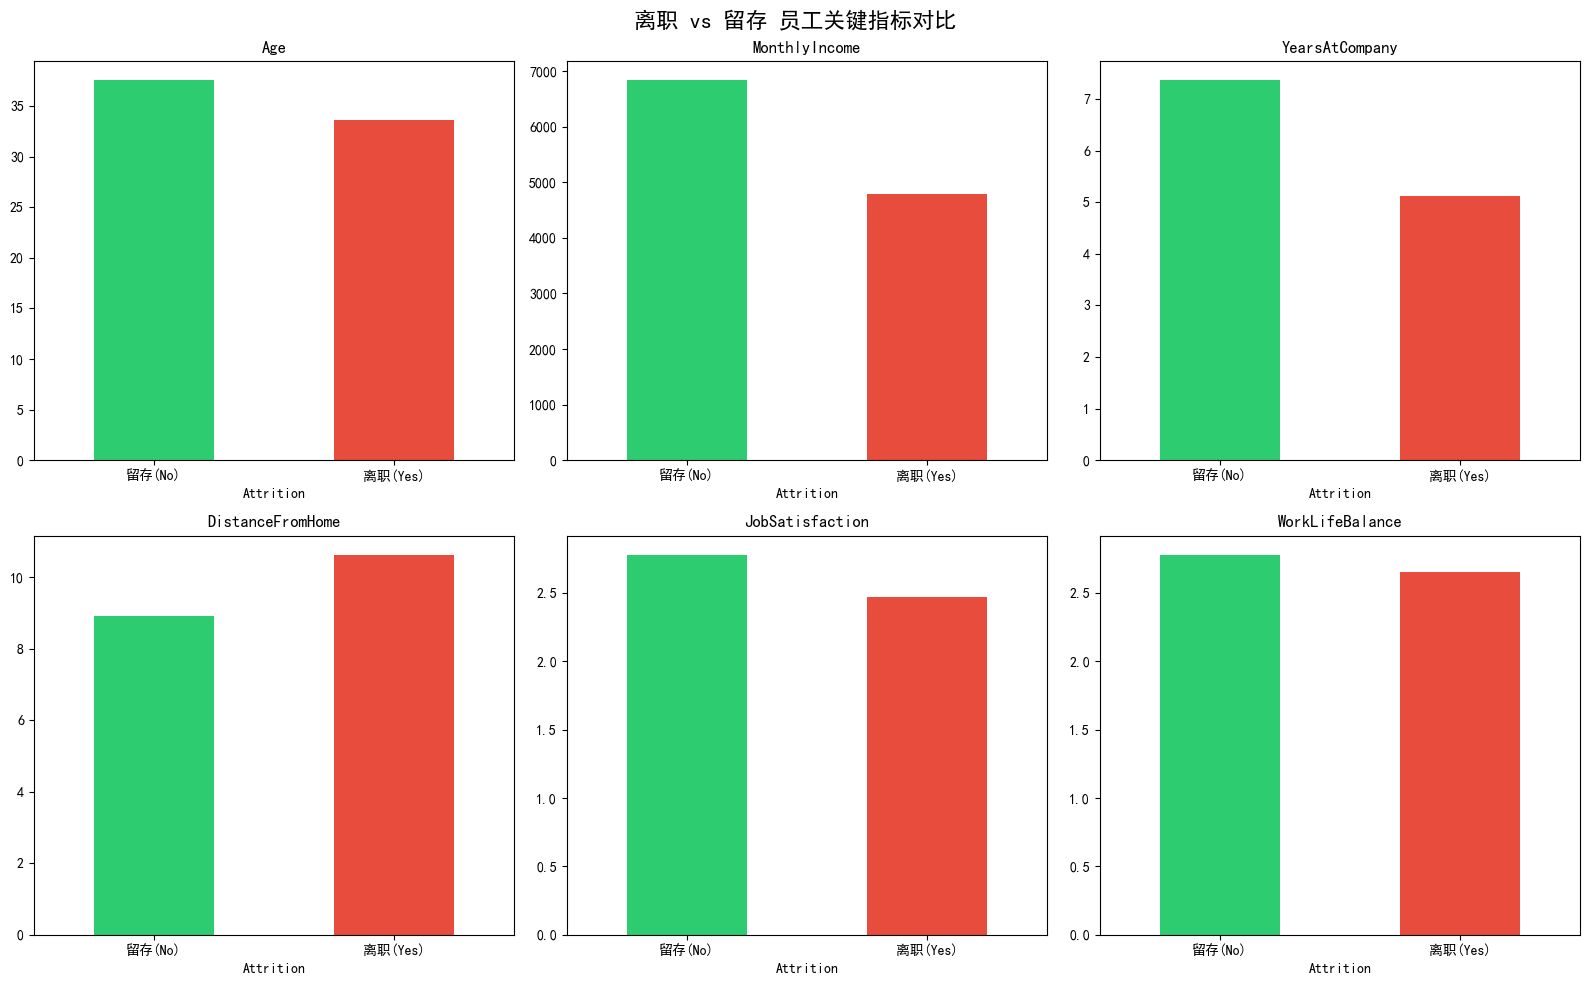

In [4]:
# 先删除无意义的列
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# 离职 vs 未离职 关键指标对比
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('离职 vs 留存 员工关键指标对比', fontsize=16)

compare_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 
                'DistanceFromHome', 'JobSatisfaction', 'WorkLifeBalance']

for ax, col in zip(axes.flatten(), compare_cols):
    df.groupby('Attrition')[col].mean().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
    ax.set_title(col)
    ax.set_xticklabels(['留存(No)', '离职(Yes)'], rotation=0)

plt.tight_layout()
plt.show()

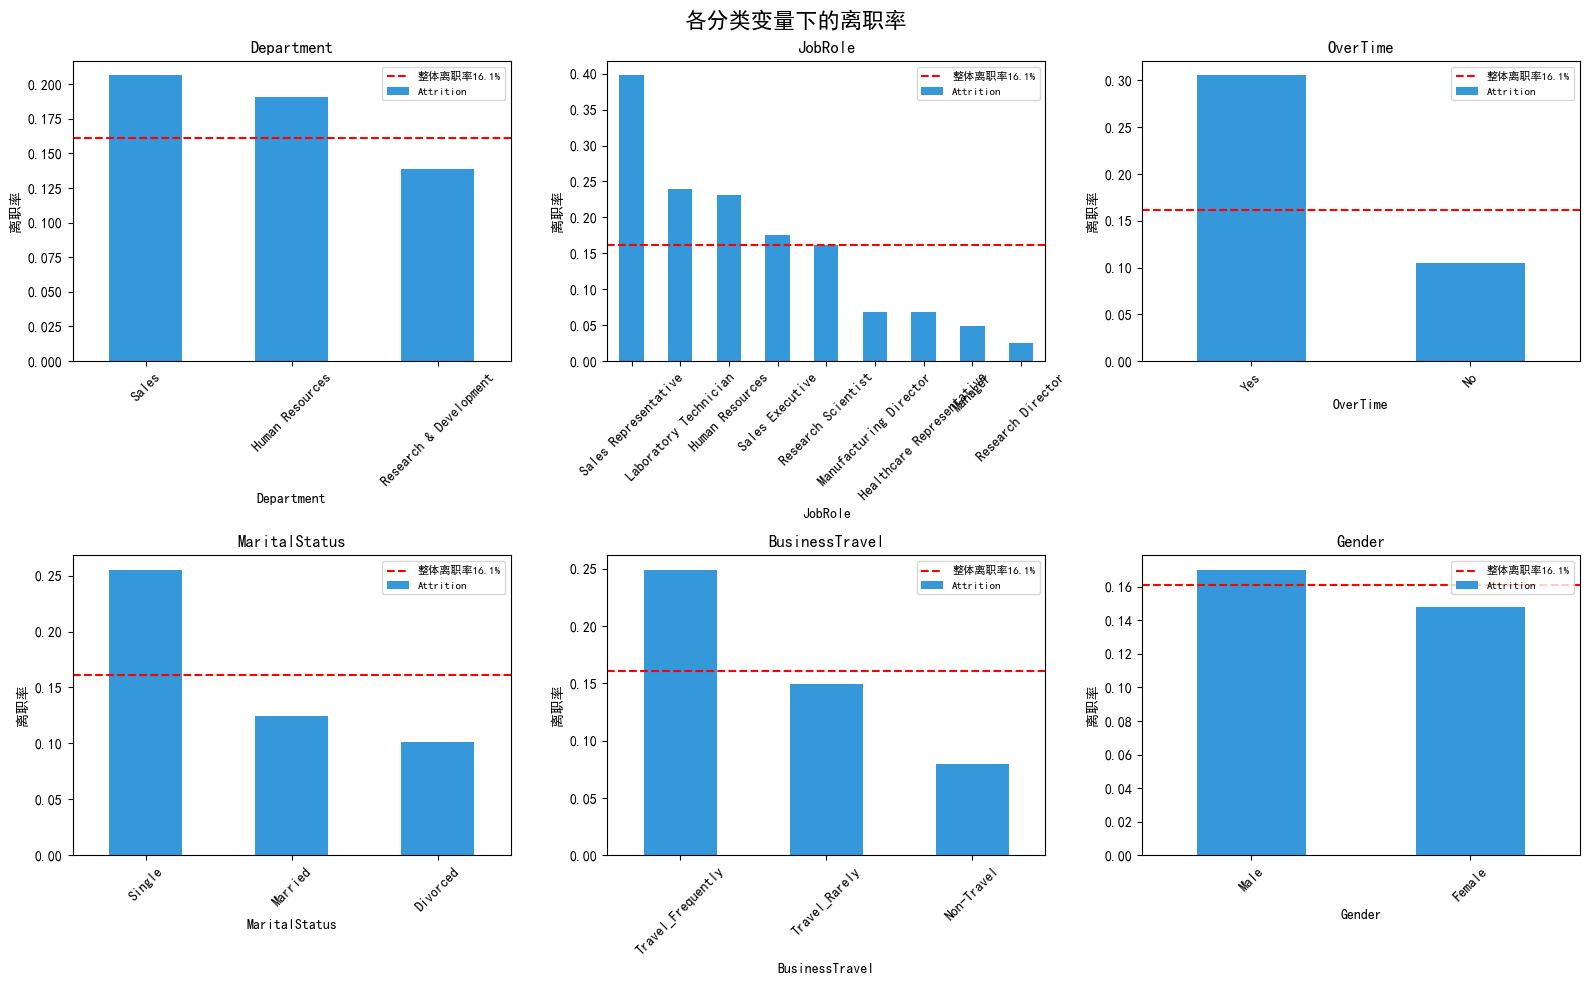

In [5]:
# 分类变量的离职率对比
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('各分类变量下的离职率', fontsize=16)

cat_cols = ['Department', 'JobRole', 'OverTime', 
            'MaritalStatus', 'BusinessTravel', 'Gender']

for ax, col in zip(axes.flatten(), cat_cols):
    rates = df.groupby(col)['Attrition'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='#3498db')
    ax.set_title(col)
    ax.set_ylabel('离职率')
    ax.axhline(y=0.161, color='red', linestyle='--', label='整体离职率16.1%')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()